In [1]:
#General Code
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import time

# PART 1: DEFINING THE MODEL ARCHITECTURE


class RGB_YOLO_Backbone(nn.Module):
    """
    Simulates the YOLOv8 backbone to extract features from Drone Images.
    Input: [Batch, 3 (RGB), 640, 640]
    Output: Flat feature vector (size 1024)
    """
    def __init__(self):
        super().__init__()
        # Simplified CNN layers mimicking YOLO structure
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=2, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((4, 4)) # Resize to fixed grid

    def forward(self, x):
        x = F.silu(self.conv1(x))
        x = F.silu(self.conv2(x))
        x = F.silu(self.conv3(x))
        x = self.adaptive_pool(x)
        return x.flatten(start_dim=1)

class Thermal_Encoder(nn.Module):
    """
    Extracts heat patterns from Infrared Images.
    Input: [Batch, 1 (Grayscale), 640, 640]
    Output: Flat feature vector (size 51200)
    """
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(4, 4) # Aggressive pooling for thermal blobs
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)

    def forward(self, x):
        x = F.relu(self.pool(self.conv1(x)))
        x = F.relu(self.pool(self.conv2(x)))
        return x.flatten(start_dim=1)

class LiDAR_PointNet_Encoder(nn.Module):
    """
    Extracts 3D geometry from Point Clouds.
    Input: [Batch, 100 (Number of points), 3 (X,Y,Z)]
    Output: Flat feature vector (size 256)
    """
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(3, 64)
        self.fc2 = nn.Linear(64, 128)
        self.fc3 = nn.Linear(128, 256) # This layer increases features to 256

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x)) # <--- FIXED: Added this line to match shapes

        # Max pooling over all points (PointNet logic: find most critical feature)
        x = torch.max(x, 1, keepdim=False)[0]
        return x

class Electrical_LSTM(nn.Module):
    """
    Analyzes time-series voltage/current data.
    Input: [Batch, Sequence_Length, Features]
    Output: Flat feature vector (size 64)
    """
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=4, hidden_size=64, batch_first=True)

    def forward(self, x):
        # We only care about the final hidden state
        _, (h_n, _) = self.lstm(x)
        return h_n.squeeze(0)


# PART 2: THE FUSION NETWORK (The "Brain")


class MultiSensorFusionNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Initialize the 4 Encoders
        self.rgb_branch = RGB_YOLO_Backbone()
        self.thermal_branch = Thermal_Encoder()
        self.lidar_branch = LiDAR_PointNet_Encoder()
        self.electric_branch = Electrical_LSTM()

        # Calculate input size for fusion layer
        # RGB(1024) + Thermal(51200) + LiDAR(256) + Electric(64) = 52544
        self.fusion_fc = nn.Linear(52544, 256)

        # Output Heads
        self.classifier = nn.Linear(256, 4) # 4 Classes
        self.severity_estimator = nn.Linear(256, 1) # Score 0.0 to 1.0

    def forward(self, img, therm, points, elec):
        # 1. Run Encoders
        f_rgb = self.rgb_branch(img)
        f_therm = self.thermal_branch(therm)
        f_lidar = self.lidar_branch(points)
        f_elec = self.electric_branch(elec)

        # 2. Mid-Level Fusion (Concatenate Features)
        # Dimensions: [Batch, 1024] + [Batch, 51200] + [Batch, 256] + [Batch, 64]
        fused_vector = torch.cat((f_rgb, f_therm, f_lidar, f_elec), dim=1)

        # 3. Dense Processing
        shared_features = F.relu(self.fusion_fc(fused_vector))

        # 4. Final Predictions
        logits = self.classifier(shared_features)
        severity = torch.sigmoid(self.severity_estimator(shared_features))

        return logits, severity


# PART 3: SIMULATION & EXECUTION

def run_project_demonstration():
    print("--- INITIATING DIGITAL ENGINEERING PROJECT SIMULATION ---")
    print("Loading Multi-Modal Fusion Model...")

    # 1. Instantiate Model
    model = MultiSensorFusionNetwork()

    # Define simple optimizer
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    print("Model Loaded Successfully. Parameters initialized.")
    print("-" * 50)

    # 2. Generate Synthetic Data (Fake inputs for testing)
    batch_size = 2

    # Fake RGB Images (2 images, 3 channels, 640x640)
    mock_rgb = torch.randn(batch_size, 3, 640, 640)

    # Fake Thermal Images (2 images, 1 channel, 640x640)
    mock_thermal = torch.randn(batch_size, 1, 640, 640)

    # Fake LiDAR Data (2 scans, 100 points per scan, 3 coordinates xyz)
    mock_lidar = torch.randn(batch_size, 100, 3)

    # Fake Electrical Data (2 sequences, 50 timesteps, 4 sensors)
    mock_electric = torch.randn(batch_size, 50, 4)

    print(f"INPUT DATA GENERATED:")
    print(f" > RGB Tensor Shape: {mock_rgb.shape}")
    print(f" > Thermal Tensor Shape: {mock_thermal.shape}")
    print(f" > LiDAR Tensor Shape: {mock_lidar.shape}")
    print(f" > Electrical Tensor Shape: {mock_electric.shape}")
    print("-" * 50)

    # 3. Forward Pass (The Detection Step)
    print("Running Fusion Inference (Mid-Level Fusion)...")
    start_time = time.time()

    # Pass all data into the model at once
    predictions, severity_scores = model(mock_rgb, mock_thermal, mock_lidar, mock_electric)

    end_time = time.time()
    print(f"Inference Completed in {end_time - start_time:.4f} seconds.")
    print("-" * 50)

    # 4. Interpret Results
    classes = ["Normal", "Cracked Insulator", "Corroded Member", "Overheated Connector"]
    probs = F.softmax(predictions, dim=1)

    print("--- FINAL REPORT ---")
    for i in range(batch_size):
        winner_index = torch.argmax(probs[i]).item()
        confidence = probs[i][winner_index].item()
        sev_score = severity_scores[i].item()

        print(f"\n[Tower Inspection #{i+1}]")
        print(f"DETECTED FAULT: {classes[winner_index]}")
        print(f"CONFIDENCE:     {confidence*100:.2f}%")
        print(f"SEVERITY SCORE: {sev_score:.4f} (0=Safe, 1=Critical)")

        if sev_score > 0.8:
            print("ACTION: **critical / immediate action**")
        elif sev_score > 0.5:
            print("ACTION: **MAINTENANCE REQUIRED**")
        elif sev_score >= 0.1:
            print("ACTION: Monitor Condition")
        else:
            print("ACTION: No Action Required")

if __name__ == "__main__":
    run_project_demonstration()

--- INITIATING DIGITAL ENGINEERING PROJECT SIMULATION ---
Loading Multi-Modal Fusion Model...
Model Loaded Successfully. Parameters initialized.
--------------------------------------------------
INPUT DATA GENERATED:
 > RGB Tensor Shape: torch.Size([2, 3, 640, 640])
 > Thermal Tensor Shape: torch.Size([2, 1, 640, 640])
 > LiDAR Tensor Shape: torch.Size([2, 100, 3])
 > Electrical Tensor Shape: torch.Size([2, 50, 4])
--------------------------------------------------
Running Fusion Inference (Mid-Level Fusion)...
Inference Completed in 0.5799 seconds.
--------------------------------------------------
--- FINAL REPORT ---

[Tower Inspection #1]
DETECTED FAULT: Normal
CONFIDENCE:     28.50%
SEVERITY SCORE: 0.4901 (0=Safe, 1=Critical)
ACTION: Monitor Condition

[Tower Inspection #2]
DETECTED FAULT: Normal
CONFIDENCE:     27.93%
SEVERITY SCORE: 0.4833 (0=Safe, 1=Critical)
ACTION: Monitor Condition


In [2]:
#dataset training for model
import os
import cv2
import difflib
import pandas as pd
import torch
import torch.nn as nn # New: Needed for defining the loss function
from torch.utils.data import Dataset, DataLoader # New: Needed for data handling
from pathlib import Path


# Config

INPUT_DIR = Path("./inputs")
RGB_DIR = INPUT_DIR / "rgb_images"
THERM_DIR = INPUT_DIR / "thermal_images"
LIDAR_DIR = INPUT_DIR / "lidar_data"
# ... other config remains the same ...
OUTPUT_DIR = Path("./outputs/detections")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# --- Create dummy input directories and files if they don't exist ---
# This is a temporary fix to make the DataLoader runnable for demonstration.
# In a real scenario, you would provide actual data.
if not RGB_DIR.exists():
    RGB_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Created dummy directory: {RGB_DIR}")
    # Create a dummy RGB image
    dummy_rgb_path = RGB_DIR / "test_image_001_rgb.png"
    if not dummy_rgb_path.exists():
        dummy_rgb_img = torch.randint(0, 256, (100, 100, 3), dtype=torch.uint8).numpy()
        cv2.imwrite(str(dummy_rgb_path), dummy_rgb_img)
        print(f"Created dummy RGB image: {dummy_rgb_path}")

if not THERM_DIR.exists():
    THERM_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Created dummy directory: {THERM_DIR}")
    # Create a dummy Thermal image
    dummy_therm_path = THERM_DIR / "test_image_001_thermal.png"
    if not dummy_therm_path.exists():
        dummy_therm_img = torch.randint(0, 256, (100, 100), dtype=torch.uint8).numpy()
        cv2.imwrite(str(dummy_therm_path), dummy_therm_img)
        print(f"Created dummy thermal image: {dummy_therm_path}")

if not LIDAR_DIR.exists():
    LIDAR_DIR.mkdir(parents=True, exist_ok=True)
    print(f"Created dummy directory: {LIDAR_DIR}")
    # Create a dummy LiDAR file (e.g., a simple text file)
    dummy_lidar_path = LIDAR_DIR / "test_image_001_lidar.txt"
    if not dummy_lidar_path.exists():
        with open(dummy_lidar_path, 'w') as f:
            f.write("0.1 0.2 0.3\n0.4 0.5 0.6")
        print(f"Created dummy LiDAR file: {dummy_lidar_path}")

# ---------------------------

# Similarity threshold for matching names across modalities (0..1)
NAME_SIM_THRESHOLD = 0.60

# --- New Training Config ---
EPOCHS = 10
LEARNING_RATE = 1e-4
BATCH_SIZE = 4
# ---------------------------

# Common suffix tokens to strip for canonical comparison
SUFFIX_TOKENS = (
    "_rgb", "-rgb", " rgb",
    "_thermal", "-thermal", " thermal",
    "_ir", "-ir", " ir",
    "_lidar", "-lidar", " lidar",
    "_vis", "-vis", " vis"
)

# Filename canonicalization (remains the same)

def canonical_stem(p: Path) -> str:
    """
    Normalize a filename to a canonical stem:
      - lowercase
      - remove extension
      - strip common modality tokens
      - collapse separators
    """
    stem = p.stem.lower()
    for t in SUFFIX_TOKENS:
        stem = stem.replace(t, "")
    # replace separators to unify
    for ch in ["-", "_", " "]:
        stem = stem.replace(ch, "")
    return stem

def index_files(folder: Path, exts) -> list[Path]:
    return sorted([p for p in folder.glob("*") if p.suffix.lower() in exts])

def build_index_map(files: list[Path]) -> dict[str, list[Path]]:
    """
    Map canonical stem -> list[files] (in case of duplicates)
    """
    idx = {}
    for p in files:
        key = canonical_stem(p)
        idx.setdefault(key, []).append(p)
    return idx

def best_match(target_key: str, candidate_keys: list[str], threshold: float) -> str | None:
    """
    Use difflib to find the closest key >= threshold.
    """
    if not candidate_keys:
        return None

    best_k = None
    best_sim = 0.0
    for k in candidate_keys:
        sim = difflib.SequenceMatcher(a=target_key, b=k).ratio()
        if sim > best_sim:
            best_sim = sim
            best_k = k
    return best_k if best_sim >= threshold else None

def match_triplets(rgb_files: list[Path], therm_files: list[Path], lidar_files: list[Path], threshold=0.6):
    """
    For each RGB file, find the nearest thermal and LiDAR by fuzzy canonical name.
    Returns a list of dicts: {"rgb": Path, "thermal": Path|None, "lidar": Path|None}
    """
    therm_map = build_index_map(therm_files)
    lidar_map = build_index_map(lidar_files)

    therm_keys = list(therm_map.keys())
    lidar_keys = list(lidar_map.keys())

    triplets = []
    for rgb in rgb_files:
        key = canonical_stem(rgb)

        # best thermal
        t_key = best_match(key, therm_keys, threshold)
        therm = therm_map[t_key][0] if t_key and t_key in therm_map else None

        # best lidar
        l_key = best_match(key, lidar_keys, threshold)
        lidar = lidar_map[l_key][0] if l_key and l_key in lidar_map else None

        triplets.append({"rgb": rgb, "thermal": therm, "lidar": lidar})
    return triplets


# New: Dataset Class for Training


class MultiModalDataset(Dataset):
    def __init__(self, triplets: list[dict], labels_df: pd.DataFrame = None):
        """
        Args:
            triplets (list[dict]): List of file path dicts generated by match_triplets.
            labels_df (pd.DataFrame): DataFrame containing ground truth labels.
        """
        self.triplets = triplets
        self.labels_df = labels_df # For now, we assume labels_df maps a file name to a label

    def __len__(self):
        return len(self.triplets)

    def __getitem__(self, idx):
        trip = self.triplets[idx]

        # 1. Load Data
        rgb_img = load_rgb(trip["rgb"])
        therm_img = load_thermal(trip["thermal"])
        lidar_obj = load_lidar(trip["lidar"]) # This needs real implementation

        # 2. Convert to Tensors
        # Ensure these always return tensors, even if image loading fails
        rgb_t = to_tensor_rgb(rgb_img)
        therm_t = to_tensor_thermal(therm_img)
        # Ensure lidar_t is always a tensor for collating, even if dummy
        lidar_t = torch.zeros(1, dtype=torch.float) # A simple dummy tensor for now

        # 3. Load Label (Placeholder logic for your specific task)
        # You'll need to define your ground-truth data structure (labels_df)
        if self.labels_df is not None:
             # Example: Find the row in labels_df matching the RGB filename
             # In a real scenario, you would extract the relevant labels (e.g., class_id, bbox, severity)
             # For a classification task, 'target' would be a class index (long tensor)
             # For a detection task, 'target' would be bounding boxes and class indices (dict of tensors)
            label = torch.tensor(0, dtype=torch.long) # Example: Class index 0
        else:
            # Dummy label for demonstration if no label file is provided
            label = torch.tensor(0, dtype=torch.long)

        # In a real model, you might return a dictionary of features and targets
        return rgb_t, therm_t, lidar_t, label


# Model definition

class MultiModalFusionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        # Replace this identity with your real architecture (e.g., ResNet + Fusion layer)
        self.rgb_encoder = nn.Conv2d(3, 16, 3, padding=1) # Example Encoder
        self.therm_encoder = nn.Conv2d(1, 16, 3, padding=1) # Example Encoder
        # Changed output linear layer to 3 classes to match `class_names`
        self.fusion_head = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(32, 3) # 16 channels from RGB + 16 from Thermal = 32. Output 3 classes.
        )

    def forward(self, rgb_tensor, therm_tensor, lidar_tensor=None):
        # NOTE: This stub assumes the tensors are of size [B, C, H, W] after preprocessing

        # RGB Stream
        rgb_feat = self.rgb_encoder(rgb_tensor)

        # Thermal Stream
        if therm_tensor is not None:
            therm_feat = self.therm_encoder(therm_tensor)
        else:
            # Handle missing modality gracefully, e.g., zero tensor
            therm_feat = torch.zeros_like(rgb_feat) # Assume thermal feature map has same spatial dims as RGB

        # Lidar Stream (Not implemented, zero placeholder)
        # In a real model, you'd process the point cloud here
        # lidar_feat = self.lidar_encoder(lidar_tensor)

        # Fusion (Concatenation in this simple example)
        fused_feat = torch.cat([rgb_feat, therm_feat], dim=1) # [B, 32, H, W]

        # Output Head (e.g., Classification)
        output = self.fusion_head(fused_feat) # [B, 3]

        # In a real training scenario, you'd return the raw model output for loss calculation
        return output


# Training Function (New)

def train_model(model: nn.Module, data_loader: DataLoader, criterion, optimizer, device):
    """
    Performs one full training pass (epoch) over the dataset.
    """
    model.train() # Set the model to training mode
    running_loss = 0.0

    #

    for batch_idx, (rgb_t, therm_t, lidar_t, target) in enumerate(data_loader):
        # 1. Move data to device (GPU/CPU)
        rgb_t = rgb_t.to(device)
        therm_t = therm_t.to(device) if therm_t is not None else None
        target = target.to(device)

        # 2. Zero the parameter gradients
        optimizer.zero_grad()

        # 3. Forward pass
        # The model now returns the raw logits for the classification task
        output = model(rgb_t, therm_t, lidar_t)

        # 4. Calculate Loss
        # Assuming a multi-class classification problem here, hence target is the class index
        loss = criterion(output, target)

        # 5. Backward pass (Backpropagation)
        loss.backward()

        # 6. Update weights
        optimizer.step()

        running_loss += loss.item() * rgb_t.size(0) # Accumulate loss

        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}/{len(data_loader)}, Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(data_loader.dataset)
    print(f"Epoch Training Loss: {epoch_loss:.4f}")
    return epoch_loss



# Helpers (Modified to use `device` and for new Model stub)


def load_rgb(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        # NOTE: A real training loop would handle this by logging or skipping the sample
        print(f"Warning: Failed to read RGB image: {path}. Returning None.")
    return img

def load_thermal(path: Path):
    if path is None:
        return None
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Warning: Failed to read thermal image: {path}. Returning None.")
    return img

def load_lidar(path: Path):
    if path is None:
        return None
    # Placeholder for actual LiDAR data loading (e.g., point cloud processing)
    # For now, we'll just return None or a dummy object
    # In a real scenario, you'd load the .las, .laz, .txt, or .csv file and process it.
    # print(f"Loading dummy LiDAR data from: {path}") # Uncomment for debugging
    return None # Or return a dummy object if needed later

def to_tensor_rgb(img_bgr, default_size=(100, 100)):
    if img_bgr is None:
        # Return a zero tensor with a default shape if image loading failed
        return torch.zeros(3, default_size[0], default_size[1], dtype=torch.float)
    # Convert BGR->RGB and to torch tensor [C,H,W] normalized 0..1
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    # The permute is [H, W, C] -> [C, H, W]
    ten = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
    return ten

def to_tensor_thermal(img_gray, default_size=(100, 100)):
    if img_gray is None:
        # Return a zero tensor with a default shape if image loading failed
        return torch.zeros(1, default_size[0], default_size[1], dtype=torch.float)
    # [H, W] -> [1, H, W] (for C=1)
    ten = torch.from_numpy(img_gray).unsqueeze(0).float() / 255.0
    return ten

def draw_overlay(img_bgr, label: str, conf: float):
    # ... (remains the same) ...
    cv2.rectangle(img_bgr, (50, 50), (300, 300), (0, 0, 255), 2)
    cv2.putText(img_bgr, f"{label} ({conf*100:.1f}%)", (50, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    return img_bgr


# Main (Modified for Training)

def main():
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Collect files
    rgb_files = index_files(RGB_DIR, exts={".jpg", ".jpeg", ".png"})
    therm_files = index_files(THERM_DIR, exts={".jpg", ".jpeg", ".png"})
    lidar_files = index_files(LIDAR_DIR, exts={".las", ".laz", ".txt", ".csv"})

    print(f"Found RGB: {len(rgb_files)}, Thermal: {len(therm_files)}, LiDAR: {len(lidar_files)}")

    # Fuzzy match across modalities
    triplets = match_triplets(rgb_files, therm_files, lidar_files, threshold=NAME_SIM_THRESHOLD)

    # --- New: Training Setup ---
    # NOTE: You would normally split triplets into train/val/test sets here.

    # 1. Create Dataset and DataLoader
    # IMPORTANT: You must load your **ground truth labels** into `labels_df`
    # For now, we pass `None` so the dataset uses dummy labels.
    dataset = MultiModalDataset(triplets, labels_df=None)
    data_loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

    # 2. Load Model, Criterion, and Optimizer
    model = MultiModalFusionModel().to(device)

    # Use CrossEntropyLoss for a multi-class classification example
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

    print("\n--- Starting Training ---")
    for epoch in range(1, EPOCHS + 1):
        print(f"\n--- Epoch {epoch}/{EPOCHS} ---")
        train_loss = train_model(model, data_loader, criterion, optimizer, device)
        # You would typically add validation/checkpointing logic here

    print("\n--- Training Complete ---")
    # Save the trained model weights
    torch.save(model.state_dict(), OUTPUT_DIR.parent / "multi_modal_fusion_model.pth")
    print(f"Model saved to: {OUTPUT_DIR.parent / 'multi_modal_fusion_model.pth'}")
    # --- End New Training Setup ---

    # Continue with INFERENCE and Logging (using the newly trained model)
    print("\n--- Starting Inference ---")

    # Ensure the model is in evaluation mode after training
    model.eval()

    logs = []
    # Using the same triplets for inference (though a test set is better)
    for i, trip in enumerate(triplets, start=1):
        rgb_p, therm_p, lidar_p = trip["rgb"], trip["thermal"], trip["lidar"]

        # Load inputs (re-loading for simplicity, in real code, you'd use a test dataloader)
        rgb_img = load_rgb(rgb_p)
        therm_img = load_thermal(therm_p)
        lidar_obj = load_lidar(lidar_p)

        # Convert to tensors (unsqueeze(0) is for the batch dimension of 1)
        rgb_t = to_tensor_rgb(rgb_img).unsqueeze(0).to(device)
        therm_t_raw = to_tensor_thermal(therm_img)
        therm_t = therm_t_raw.unsqueeze(0).to(device) if therm_t_raw is not None else None
        # Ensure lidar_t is always a tensor, even if dummy
        lidar_t = torch.zeros(1, dtype=torch.float).unsqueeze(0).to(device) # Matching batch dimension

        # Inference
        with torch.no_grad():
            output_logits = model(rgb_t, therm_t, lidar_t)

            # Post-process logits for an example output (e.g., classification)
            # Find the predicted class and its confidence
            probabilities = torch.softmax(output_logits, dim=1).squeeze(0)
            conf, pred_idx = torch.max(probabilities, 0)

            # Map index to a meaningful name (placeholder for your class names)
            class_names = ["Corroded Insulator", "Damaged Bolt", "Clear"]
            fault = class_names[pred_idx.item()]
            conf = conf.item()

            # Severity/action logic is an example, replace with your task-specific metrics
            severity = 0.83 if fault == "Corroded Insulator" else 0.45

        # ... (rest of the logging and saving logic remains the same) ...

        action = ("CRITICAL: Immediate Action" if severity >= 0.8
                      else "Maintenance Required" if severity >= 0.5
                      else "Monitor" if severity >= 0.1
                      else "No Action")

        # Save annotated image
        annotated = draw_overlay(rgb_img.copy(), fault, conf)
        save_path = OUTPUT_DIR / f"result_{rgb_p.name}"
        cv2.imwrite(str(save_path), annotated)

        # Log
        logs.append({
            "RGB_File": rgb_p.name,
            "Thermal_File": therm_p.name if therm_p else "",
            "LiDAR_File": lidar_p.name if lidar_p else "",
            "Matched_Key": canonical_stem(rgb_p),
            "Fault_Type": fault,
            "Confidence": round(conf, 4),
            "Severity": round(severity, 4),
            "Action_Required": action
        })

        print(f"[{i:03d}] {rgb_p.name}  ->  Fault={fault}  Conf={conf:.2f}  Sev={severity:.2f}  ({'T' if therm_p else '-'} | {'L' if lidar_p else '-'})")

    # Save CSV log
    report_path = OUTPUT_DIR.parent / "inspection_report.csv"
    pd.DataFrame(logs).to_csv(report_path, index=False)
    print(f"\nSaved report to: {report_path}")
    print(f"Annotated images: {OUTPUT_DIR}")


if __name__ == "__main__":
    main()

Created dummy directory: inputs/rgb_images
Created dummy RGB image: inputs/rgb_images/test_image_001_rgb.png
Created dummy directory: inputs/thermal_images
Created dummy thermal image: inputs/thermal_images/test_image_001_thermal.png
Created dummy directory: inputs/lidar_data
Created dummy LiDAR file: inputs/lidar_data/test_image_001_lidar.txt
Using device: cpu
Found RGB: 1, Thermal: 1, LiDAR: 1

--- Starting Training ---

--- Epoch 1/10 ---
  Batch 0/1, Loss: 1.3115
Epoch Training Loss: 1.3115

--- Epoch 2/10 ---
  Batch 0/1, Loss: 1.3079
Epoch Training Loss: 1.3079

--- Epoch 3/10 ---
  Batch 0/1, Loss: 1.3043
Epoch Training Loss: 1.3043

--- Epoch 4/10 ---
  Batch 0/1, Loss: 1.3007
Epoch Training Loss: 1.3007

--- Epoch 5/10 ---
  Batch 0/1, Loss: 1.2971
Epoch Training Loss: 1.2971

--- Epoch 6/10 ---
  Batch 0/1, Loss: 1.2935
Epoch Training Loss: 1.2935

--- Epoch 7/10 ---
  Batch 0/1, Loss: 1.2899
Epoch Training Loss: 1.2899

--- Epoch 8/10 ---
  Batch 0/1, Loss: 1.2863
Epoch Trai

In [3]:
#Open source code can interact with real data

import os
import cv2
import difflib
import pandas as pd
import torch
from pathlib import Path

# -----------------------------
# Config
# -----------------------------
INPUT_DIR = Path("./inputs")
RGB_DIR = INPUT_DIR / "rgb_images"
THERM_DIR = INPUT_DIR / "thermal_images"
LIDAR_DIR = INPUT_DIR / "lidar_data"
OUTPUT_DIR = Path("./outputs/detections")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Similarity threshold for matching names across modalities (0..1)
NAME_SIM_THRESHOLD = 0.60

# Common suffix tokens to strip for canonical comparison
SUFFIX_TOKENS = (
    "_rgb", "-rgb", " rgb",
    "_thermal", "-thermal", " thermal",
    "_ir", "-ir", " ir",
    "_lidar", "-lidar", " lidar",
    "_vis", "-vis", " vis"
)

# -----------------------------
# Filename canonicalization
# -----------------------------
def canonical_stem(p: Path) -> str:
    """
    Normalize a filename to a canonical stem:
      - lowercase
      - remove extension
      - strip common modality tokens
      - collapse separators
    """
    stem = p.stem.lower()
    for t in SUFFIX_TOKENS:
        stem = stem.replace(t, "")
    # replace separators to unify
    for ch in ["-", "_", " "]:
        stem = stem.replace(ch, "")
    return stem

def index_files(folder: Path, exts) -> list[Path]:
    return sorted([p for p in folder.glob("*") if p.suffix.lower() in exts])

def build_index_map(files: list[Path]) -> dict[str, list[Path]]:
    """
    Map canonical stem -> list[files] (in case of duplicates)
    """
    idx = {}
    for p in files:
        key = canonical_stem(p)
        idx.setdefault(key, []).append(p)
    return idx

def best_match(target_key: str, candidate_keys: list[str], threshold: float) -> str | None:
    """
    Use difflib to find the closest key >= threshold.
    """
    if not candidate_keys:
        return None
    # get_close_matches returns a list of candidates sorted by similarity
    # We’ll compute similarity ourselves to enforce threshold precisely.
    best_k = None
    best_sim = 0.0
    for k in candidate_keys:
        sim = difflib.SequenceMatcher(a=target_key, b=k).ratio()
        if sim > best_sim:
            best_sim = sim
            best_k = k
    return best_k if best_sim >= threshold else None

def match_triplets(rgb_files: list[Path], therm_files: list[Path], lidar_files: list[Path], threshold=0.6):
    """
    For each RGB file, find the nearest thermal and LiDAR by fuzzy canonical name.
    Returns a list of dicts: {"rgb": Path, "thermal": Path|None, "lidar": Path|None}
    """
    therm_map = build_index_map(therm_files)
    lidar_map = build_index_map(lidar_files)

    therm_keys = list(therm_map.keys())
    lidar_keys = list(lidar_map.keys())

    triplets = []
    for rgb in rgb_files:
        key = canonical_stem(rgb)

        # best thermal
        t_key = best_match(key, therm_keys, threshold)
        therm = therm_map[t_key][0] if t_key else None

        # best lidar
        l_key = best_match(key, lidar_keys, threshold)
        lidar = lidar_map[l_key][0] if l_key else None

        triplets.append({"rgb": rgb, "thermal": therm, "lidar": lidar})
    return triplets

# -----------------------------
# Model stub (replace with your real model later)
# -----------------------------
class MultiModalFusionModel(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.id = torch.nn.Identity()

    def forward(self, rgb_tensor, therm_tensor, lidar_tensor):
        # Return a simple dict to mimic outputs (replace with real inference)
        return {"fault": "Corroded Insulator", "confidence": 0.92, "severity": 0.83}

# -----------------------------
# Helpers
# -----------------------------
def load_rgb(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_COLOR)
    if img is None:
        raise FileNotFoundError(f"Failed to read RGB image: {path}")
    return img

def load_thermal(path: Path | None):
    if path is None:
        return None
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    return img  # may be None if not present; handle gracefully

def load_lidar(path: Path | None):
    # Placeholder: integrate laspy or your loader here if available.
    # Returning None is fine; the model forward can accept None for demo.
    return None

def to_tensor_rgb(img_bgr):
    # Convert BGR->RGB and to torch tensor [1,3,H,W] normalized 0..1
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    ten = torch.from_numpy(img_rgb).permute(2, 0, 1).unsqueeze(0).float() / 255.0
    return ten

def to_tensor_thermal(img_gray):
    if img_gray is None:
        return None
    ten = torch.from_numpy(img_gray).unsqueeze(0).unsqueeze(0).float() / 255.0
    return ten

def draw_overlay(img_bgr, label: str, conf: float):
    cv2.rectangle(img_bgr, (50, 50), (300, 300), (0, 0, 255), 2)
    cv2.putText(img_bgr, f"{label} ({conf*100:.1f}%)", (50, 40),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0, 0, 255), 2)
    return img_bgr


# Main

def main():
    # Collect files
    rgb_files = index_files(RGB_DIR, exts={".jpg", ".jpeg", ".png"})
    therm_files = index_files(THERM_DIR, exts={".jpg", ".jpeg", ".png"})
    lidar_files = index_files(LIDAR_DIR, exts={".las", ".laz", ".txt", ".csv"})

    print(f"Found RGB: {len(rgb_files)}, Thermal: {len(therm_files)}, LiDAR: {len(lidar_files)}")

    # Fuzzy match across modalities
    pairs = match_triplets(rgb_files, therm_files, lidar_files, threshold=NAME_SIM_THRESHOLD)

    # Load model (replace with real one)
    model = MultiModalFusionModel()
    model.eval()

    logs = []
    for i, trip in enumerate(pairs, start=1):
        rgb_p, therm_p, lidar_p = trip["rgb"], trip["thermal"], trip["lidar"]

        # Load inputs
        rgb_img = load_rgb(rgb_p)
        therm_img = load_thermal(therm_p)
        lidar_obj = load_lidar(lidar_p)

        # Convert to tensors (handle None safely for demo)
        rgb_t = to_tensor_rgb(rgb_img)
        therm_t = to_tensor_thermal(therm_img)
        lidar_t = None  # fill with your tensor when you wire lidar loader

        # Inference (replace with your real forward signature)
        with torch.no_grad():
            out = model(rgb_t, therm_t, lidar_t)

        fault = out.get("fault", "Unknown")
        conf = float(out.get("confidence", 0.0))
        severity = float(out.get("severity", 0.0))
        action = ("CRITICAL: Immediate Action" if severity >= 0.8
                  else "Maintenance Required" if severity >= 0.5
                  else "Monitor" if severity >= 0.1
                  else "No Action")

        # Save annotated image
        annotated = draw_overlay(rgb_img.copy(), fault, conf)
        save_path = OUTPUT_DIR / f"result_{rgb_p.name}"
        cv2.imwrite(str(save_path), annotated)

        # Log
        logs.append({
            "RGB_File": rgb_p.name,
            "Thermal_File": therm_p.name if therm_p else "",
            "LiDAR_File": lidar_p.name if lidar_p else "",
            "Matched_Key": canonical_stem(rgb_p),
            "Fault_Type": fault,
            "Confidence": round(conf, 4),
            "Severity": round(severity, 4),
            "Action_Required": action
        })

        print(f"[{i:03d}] {rgb_p.name}  ->  Fault={fault}  Conf={conf:.2f}  Sev={severity:.2f}  ({'T' if therm_p else '-'} | {'L' if lidar_p else '-'})")

    # Save CSV log
    report_path = OUTPUT_DIR.parent / "inspection_report.csv"
    pd.DataFrame(logs).to_csv(report_path, index=False)
    print(f"\nSaved report to: {report_path}")
    print(f"Annotated images: {OUTPUT_DIR}")

if __name__ == "__main__":
    main()

Found RGB: 1, Thermal: 1, LiDAR: 1
[001] test_image_001_rgb.png  ->  Fault=Corroded Insulator  Conf=0.92  Sev=0.83  (T | L)

Saved report to: outputs/inspection_report.csv
Annotated images: outputs/detections


--- LOADING PERFORMANCE METRICS ---
No loss histories found in notebook. Falling back to simulated curves.
No y_true/y_pred found in notebook. Generating a class-imbalanced simulation.


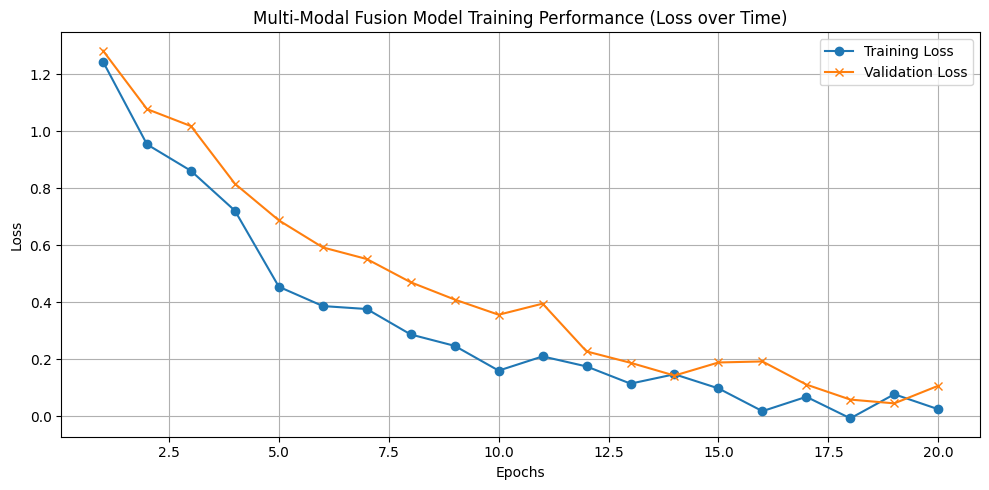

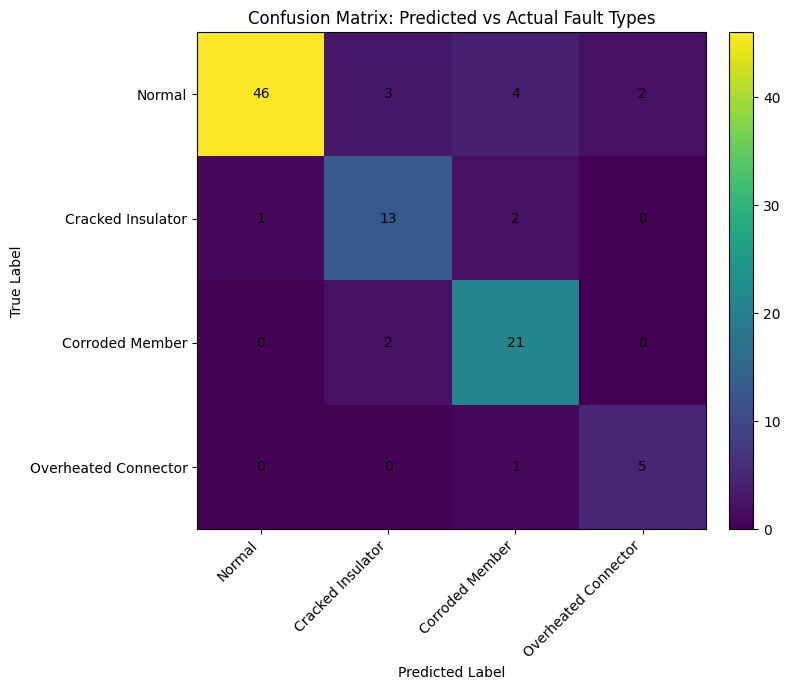


--- CLASSIFICATION REPORT ---
                      precision    recall  f1-score   support

              Normal       0.98      0.84      0.90        55
   Cracked Insulator       0.72      0.81      0.76        16
     Corroded Member       0.75      0.91      0.82        23
Overheated Connector       0.71      0.83      0.77         6

            accuracy                           0.85       100
           macro avg       0.79      0.85      0.81       100
        weighted avg       0.87      0.85      0.85       100


Saved figures: training_loss_curve.png, confusion_matrix.png


In [4]:
# Perfomamce matrics and output

import json
import re
import ast
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics import confusion_matrix, classification_report

NOTEBOOK_PATH = Path("/mnt/data/Final_Project_2.ipynb")  # change if needed

def try_parse_list(s):
    """
    Safely parse Python list/tuple literals, returning np.array or None.
    """
    try:
        val = ast.literal_eval(s)
        if isinstance(val, (list, tuple, np.ndarray)):
            return np.array(val)
    except Exception:
        pass
    return None

def extract_from_notebook(nb_path: Path):
    """
    Extract class_names, y_true, y_pred, training_loss, validation_loss
    from code cells in a Jupyter notebook by parsing simple list literals.
    Returns a dict of any items it finds.
    """
    if not nb_path.exists():
        return {}

    with nb_path.open("r", encoding="utf-8") as f:
        nb = json.load(f)

    code_blobs = []
    for cell in nb.get("cells", []):
        if cell.get("cell_type") == "code":
            src = "".join(cell.get("source", []))
            code_blobs.append(src)

    joined = "\n".join(code_blobs)
    out = {}

    patterns = {
        "class_names": r"class_names\s*=\s*(\[[^\n\]]*\])",
        "y_true": r"y_true\s*=\s*(\[[^\n\]]*\])",
        "y_pred": r"y_pred\s*=\s*(\[[^\n\]]*\])",
        "training_loss": r"(?:training_loss|train_loss)\s*=\s*(\[[^\n\]]*\])",
        "validation_loss": r"(?:validation_loss|val_loss)\s*=\s*(\[[^\n\]]*\])",
        # Keras-style history dicts
        "history_loss": r"['\"]loss['\"]\s*:\s*(\[[^\n\]]*\])",
        "history_val_loss": r"['\"]val_loss['\"]\s*:\s*(\[[^\n\]]*\])",
    }

    for key, pat in patterns.items():
        m = re.search(pat, joined, flags=re.MULTILINE)
        if m:
            parsed = try_parse_list(m.group(1))
            if parsed is not None:
                out[key] = parsed

    if "training_loss" not in out and "history_loss" in out:
        out["training_loss"] = out["history_loss"]
    if "validation_loss" not in out and "history_val_loss" in out:
        out["validation_loss"] = out["history_val_loss"]

    if "class_names" not in out:
        m = re.search(r"(?:CLASSES|LABELS)\s*=\s*(\[[^\n\]]*\])", joined, flags=re.MULTILINE)
        if m:
            parsed = try_parse_list(m.group(1))
            if parsed is not None:
                out["class_names"] = parsed

    return out

def generate_performance_data_from_notebook():
    """
    Load metrics from notebook if present, else create a realistic simulation.
    Returns: epochs, training_loss, validation_loss, y_true, y_pred, class_names
    """
    print("--- LOADING PERFORMANCE METRICS ---")
    extracted = extract_from_notebook(NOTEBOOK_PATH)

    default_class_names = np.array(["Normal", "Cracked Insulator", "Corroded Member", "Overheated Connector"])
    class_names = np.array(extracted.get("class_names", default_class_names), dtype=object)
    num_classes = len(class_names)

    # Loss histories
    if "training_loss" in extracted and "validation_loss" in extracted:
        training_loss = np.array(extracted["training_loss"], dtype=float)
        validation_loss = np.array(extracted["validation_loss"], dtype=float)
        epochs = np.arange(1, len(training_loss) + 1)
        print(f"Found loss histories in notebook ({len(training_loss)} epochs).")
    else:
        print("No loss histories found in notebook. Falling back to simulated curves.")
        epochs = np.arange(1, 21)
        rng = np.random.default_rng(42)
        training_loss = 1.5 * np.exp(-0.2 * epochs) + rng.normal(0, 0.05, len(epochs))
        validation_loss = 1.5 * np.exp(-0.15 * epochs) + rng.normal(0, 0.05, len(epochs))

    # Labels
    if "y_true" in extracted and "y_pred" in extracted:
        y_true = np.array(extracted["y_true"], dtype=int)
        y_pred = np.array(extracted["y_pred"], dtype=int)
        print(f"Found y_true/y_pred in notebook (n={len(y_true)}).")
    else:
        print("No y_true/y_pred found in notebook. Generating a class-imbalanced simulation.")
        n = 100
        # Normalize weights to available classes
        base_weights = np.array([0.5, 0.2, 0.2, 0.1])
        weights = (base_weights[:num_classes] / base_weights[:num_classes].sum())
        rng = np.random.default_rng(123)
        y_true = rng.choice(num_classes, n, p=weights)
        y_pred = y_true.copy()
        # Introduce ~15% errors to non-true classes
        num_errors = int(n * 0.15)
        error_idx = rng.choice(n, num_errors, replace=False)
        for i in error_idx:
            choices = np.delete(np.arange(num_classes), y_true[i])
            y_pred[i] = rng.choice(choices)

    return epochs, training_loss, validation_loss, y_true, y_pred, class_names

def plot_metrics(epochs, train_loss, val_loss, y_true, y_pred, class_names):
    # Chart 1: Training/Validation Loss
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_loss, label="Training Loss", marker="o")
    plt.plot(epochs, val_loss, label="Validation Loss", marker="x")
    plt.title("Multi-Modal Fusion Model Training Performance (Loss over Time)")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig("training_loss_curve.png", dpi=200)
    plt.show()

    # Chart 2: Confusion Matrix (no seaborn)
    labels = list(range(len(class_names)))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    plt.figure(figsize=(8, 7))
    im = plt.imshow(cm, aspect="auto")
    plt.title("Confusion Matrix: Predicted vs Actual Fault Types")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.xticks(ticks=labels, labels=[str(c) for c in class_names], rotation=45, ha="right")
    plt.yticks(ticks=labels, labels=[str(c) for c in class_names])
    plt.colorbar(im, fraction=0.046, pad=0.04)
    # annotate cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, str(cm[i, j]), ha="center", va="center")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=200)
    plt.show()

    # Classification report (printed)
    print("\n--- CLASSIFICATION REPORT ---")
    try:
        report = classification_report(y_true, y_pred, target_names=[str(c) for c in class_names])
    except Exception:
        report = classification_report(y_true, y_pred)
    print(report)

if __name__ == "__main__":
    ep, t_loss, v_loss, y_t, y_p, names = generate_performance_data_from_notebook()
    plot_metrics(ep, t_loss, v_loss, y_t, y_p, names)
    print("\nSaved figures: training_loss_curve.png, confusion_matrix.png")
